In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [3]:
fake['label'] = 0
true['label'] = 1

In [4]:
df = pd.concat([fake, true], axis = 0)
df = df.sample(frac = 1, random_state = 42).reset_index(drop = True)

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', '', text)
    return text

df['text'] = df['text'].apply(clean_text)

In [6]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
vectorizer = TfidfVectorizer(max_features = 5000)

X_train_vec = vectorizer.fit_transform(X_train).toarray()
X_test_vec = vectorizer.transform(X_test).toarray()

In [8]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter = 1000),
    "Naive Bayes" :  MultinomialNB()
}

In [9]:
results = []
trained_models = {}

In [10]:
for name, model in models.items():
    try:
        model.fit(X_train_vec, y_train)
        y_pred = model.predict(X_test_vec)
    
        trained_models[name] = model
    
        results.append({
            "Model" : name,
            "Accuracy" : accuracy_score(y_test, y_pred),
            "Precision" : precision_score(y_test, y_pred),
            "Recall" : recall_score(y_test, y_pred),
            "F1 Score" : f1_score(y_test, y_pred)
        })
    except Exception as e:
        print(f"Error in {name} : {e}")

In [11]:
results_df = pd.DataFrame(results)
print("\n Model Comparision: \n")
print(results_df)


 Model Comparision: 

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.499889   0.487387  1.000000  0.655360
1          Naive Bayes  0.526726   1.000000  0.004684  0.009324


In [12]:
best_model_name = results_df.sort_values(by = "Accuracy", ascending = False).iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"\n Best Model: {best_model_name}")


 Best Model: Naive Bayes


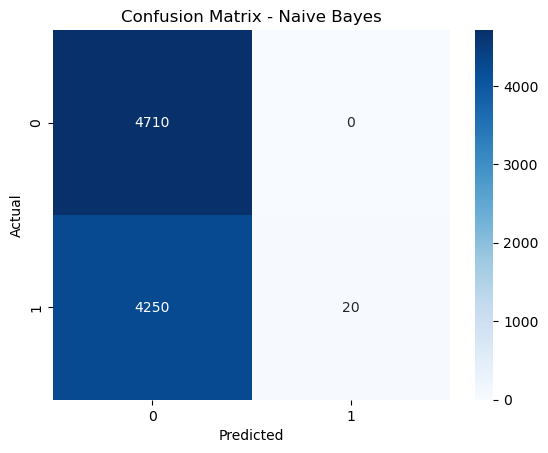

In [13]:
y_pred_best = best_model.predict(X_test_vec)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure()
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()